# Extreme Value Analysis on the simulated Discharge / stage relationship

In [2]:
!pip install arviz
!pip install pymc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 35.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [arviz]32m3/4 [arviz]-einstats]
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.1/539.1 kB 2.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 37.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 24.9 MB/s  0:00:01m0:00:0100:01
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [pymc]2m15/16 [pymc]sor]


In [3]:
# Import necessary libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats 
from scipy.optimize import curve_fit
import arviz as az
import pymc as pm

/Users/tijnspijkers/miniforge3/envs/copula/lib/python3.13/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


## Loading Data

### 1. Discharge Measurements processing

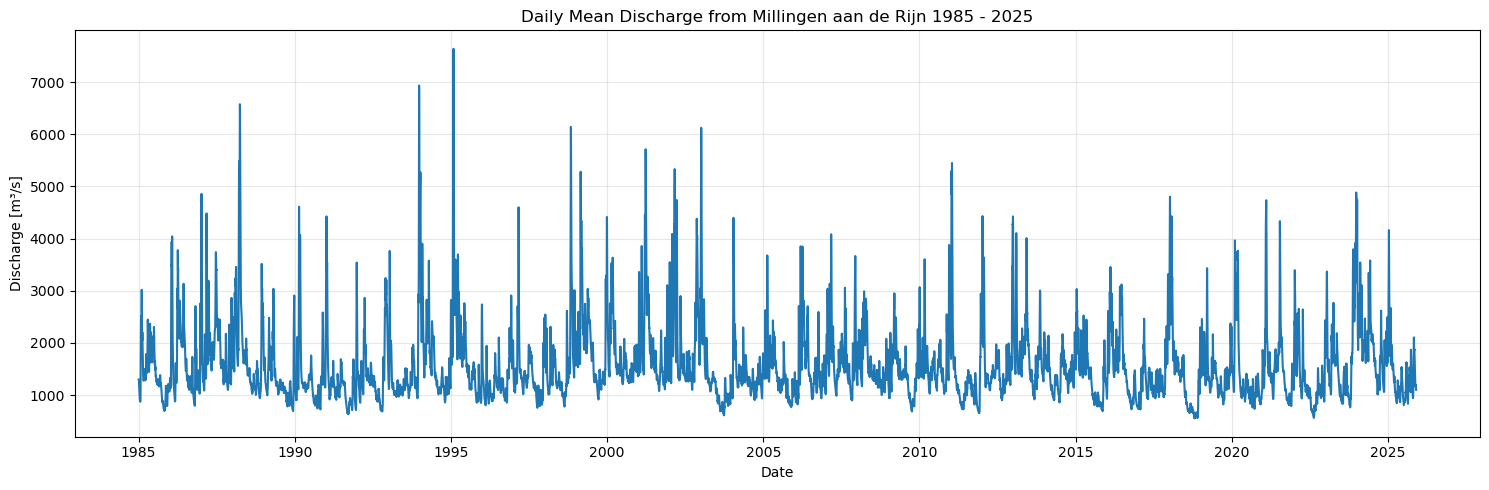

In [4]:
files = ['data/Mill1.csv', 'data/Mill2.csv', 'data/Mill3.csv', 'data/Mill4.csv']

data_frames = []

for file_name in files:
    df = pd.read_csv(file_name, sep=';', encoding="latin1")
    df["datum"] = pd.to_datetime(df["datum"], dayfirst=True)
    df["waarde"] = pd.to_numeric(df["waarde"].astype(str).str.replace(",", "."))
    df.loc[df["waarde"] > 1e5, "waarde"] = np.nan 
    df = df.dropna(subset=["datum", "waarde"]) 
    
    daily_mean = df.groupby("datum")["waarde"].mean()
    data_frames.append(daily_mean)


Q_series = pd.concat(data_frames).sort_index()
Q_series = Q_series.groupby(Q_series.index).mean() #removes overlapping dates

# Plotting
plt.figure(figsize=(15, 5))
plt.plot(Q_series.index, Q_series.values)
plt.xlabel("Date")
plt.ylabel("Discharge [m³/s]")
plt.title("Daily Mean Discharge from Millingen aan de Rijn 1985 - 2025")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2. Water level data processing

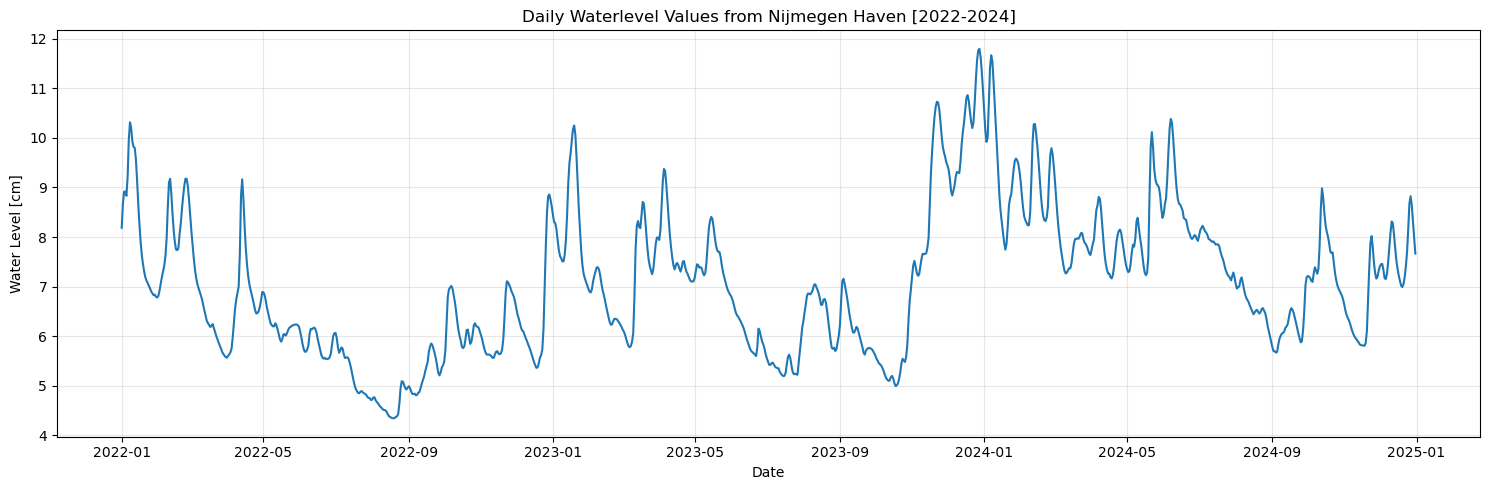

In [5]:
filename = 'data/nijmegen_haven_2022-2024.csv'

df_h = pd.read_csv(filename, sep=';', encoding="latin1")
df_h["datum"] = pd.to_datetime(df_h["WAARNEMINGDATUM"],dayfirst=True)
df_h["waarde"] = pd.to_numeric(df_h["NUMERIEKEWAARDE"].astype(str).str.replace(",", "."))
df_h.loc[df_h["waarde"] > 1e5, "waarde"] = np.nan 

df_h['waarde_meters'] = df_h['waarde'] / 100.0
df_h = df_h.dropna(subset=["datum", "waarde_meters"]) 
h_series = df_h.groupby("datum")["waarde_meters"].mean() # transform to daily mean 

# Plotting
plt.figure(figsize=(15, 5))
plt.plot(h_series.index, h_series.values)
plt.xlabel("Date")
plt.ylabel("Water Level [cm]")
plt.title(f"Daily Waterlevel Values from Nijmegen Haven [2022-2024]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Merging Discharge and water level data

Total Combined Days: 1092


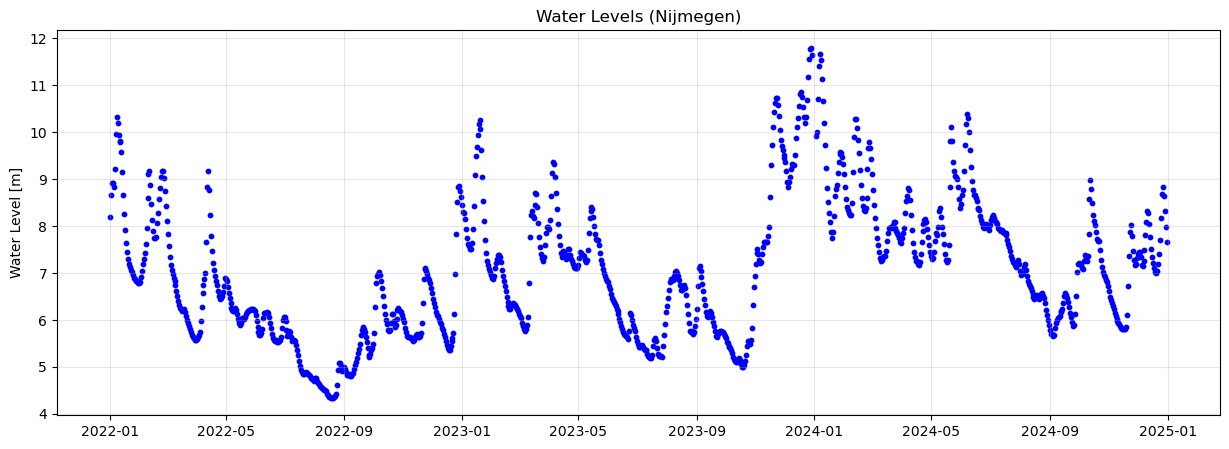

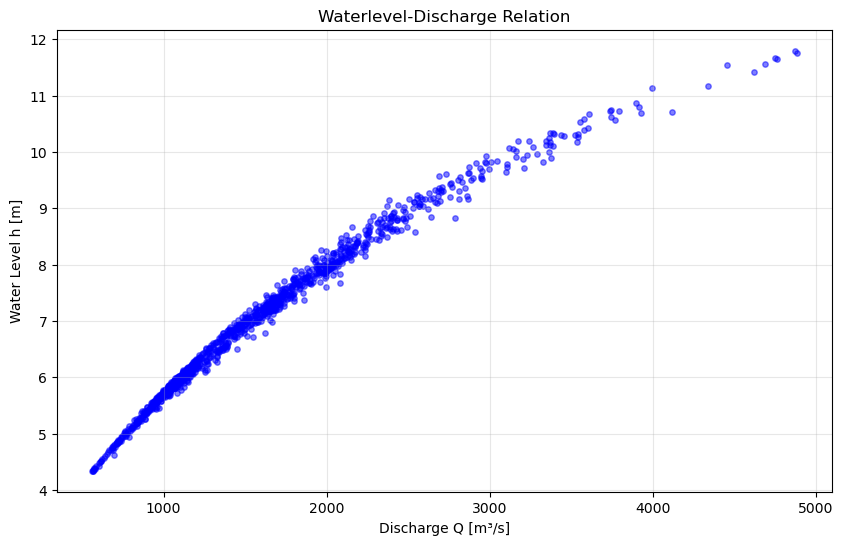

In [6]:
# Split data into training and validation sets.
combined_df = pd.concat([Q_series, h_series], axis=1, join='inner')
combined_df.columns = ['Q_m3s', 'h_meters']

print(f"Total Combined Days: {len(combined_df)}")

Q_data = combined_df['Q_m3s'].values
h_data = combined_df['h_meters'].values

plt.figure(figsize=(15, 5))
plt.scatter(combined_df.index, h_data, s=10, color='blue')
plt.title("Water Levels (Nijmegen)")
plt.ylabel("Water Level [m]")
plt.grid(True, alpha=0.3)

plt.figure(figsize=(10, 6))
plt.scatter(Q_data, h_data, s=15, alpha=0.5, color='blue')
plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water Level h [m]")
plt.title("Waterlevel-Discharge Relation")
plt.grid(True, alpha=0.3)
plt.show()

## PYMC

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [log_a, log_b, h0, log_sigma]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 115 seconds.


         mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
a      7.1348  1.1954  4.8914   9.4227     0.0300   0.0216  1570.8418   
b      2.5114  0.0533  2.4133   2.6142     0.0013   0.0010  1576.3433   
h0    -1.4940  0.1865 -1.8383  -1.1370     0.0047   0.0035  1572.2436   
sigma  0.1130  0.0024  0.1083   0.1174     0.0000   0.0000  2406.9326   

        ess_tail   r_hat  
a      1759.9551  1.0039  
b      1797.5818  1.0041  
h0     1770.0724  1.0043  
sigma  2198.1501  1.0012  


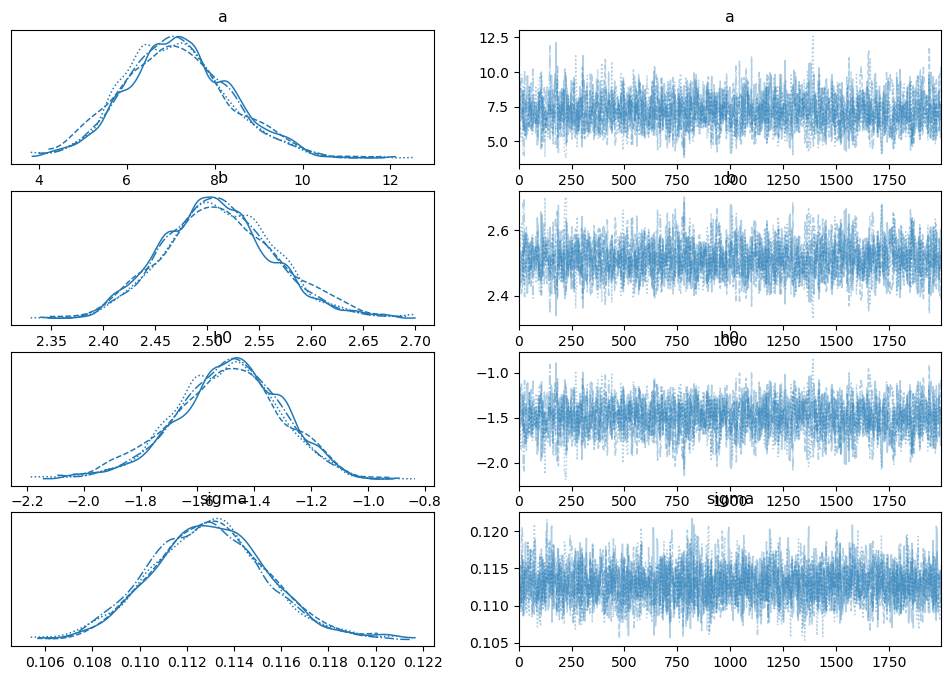

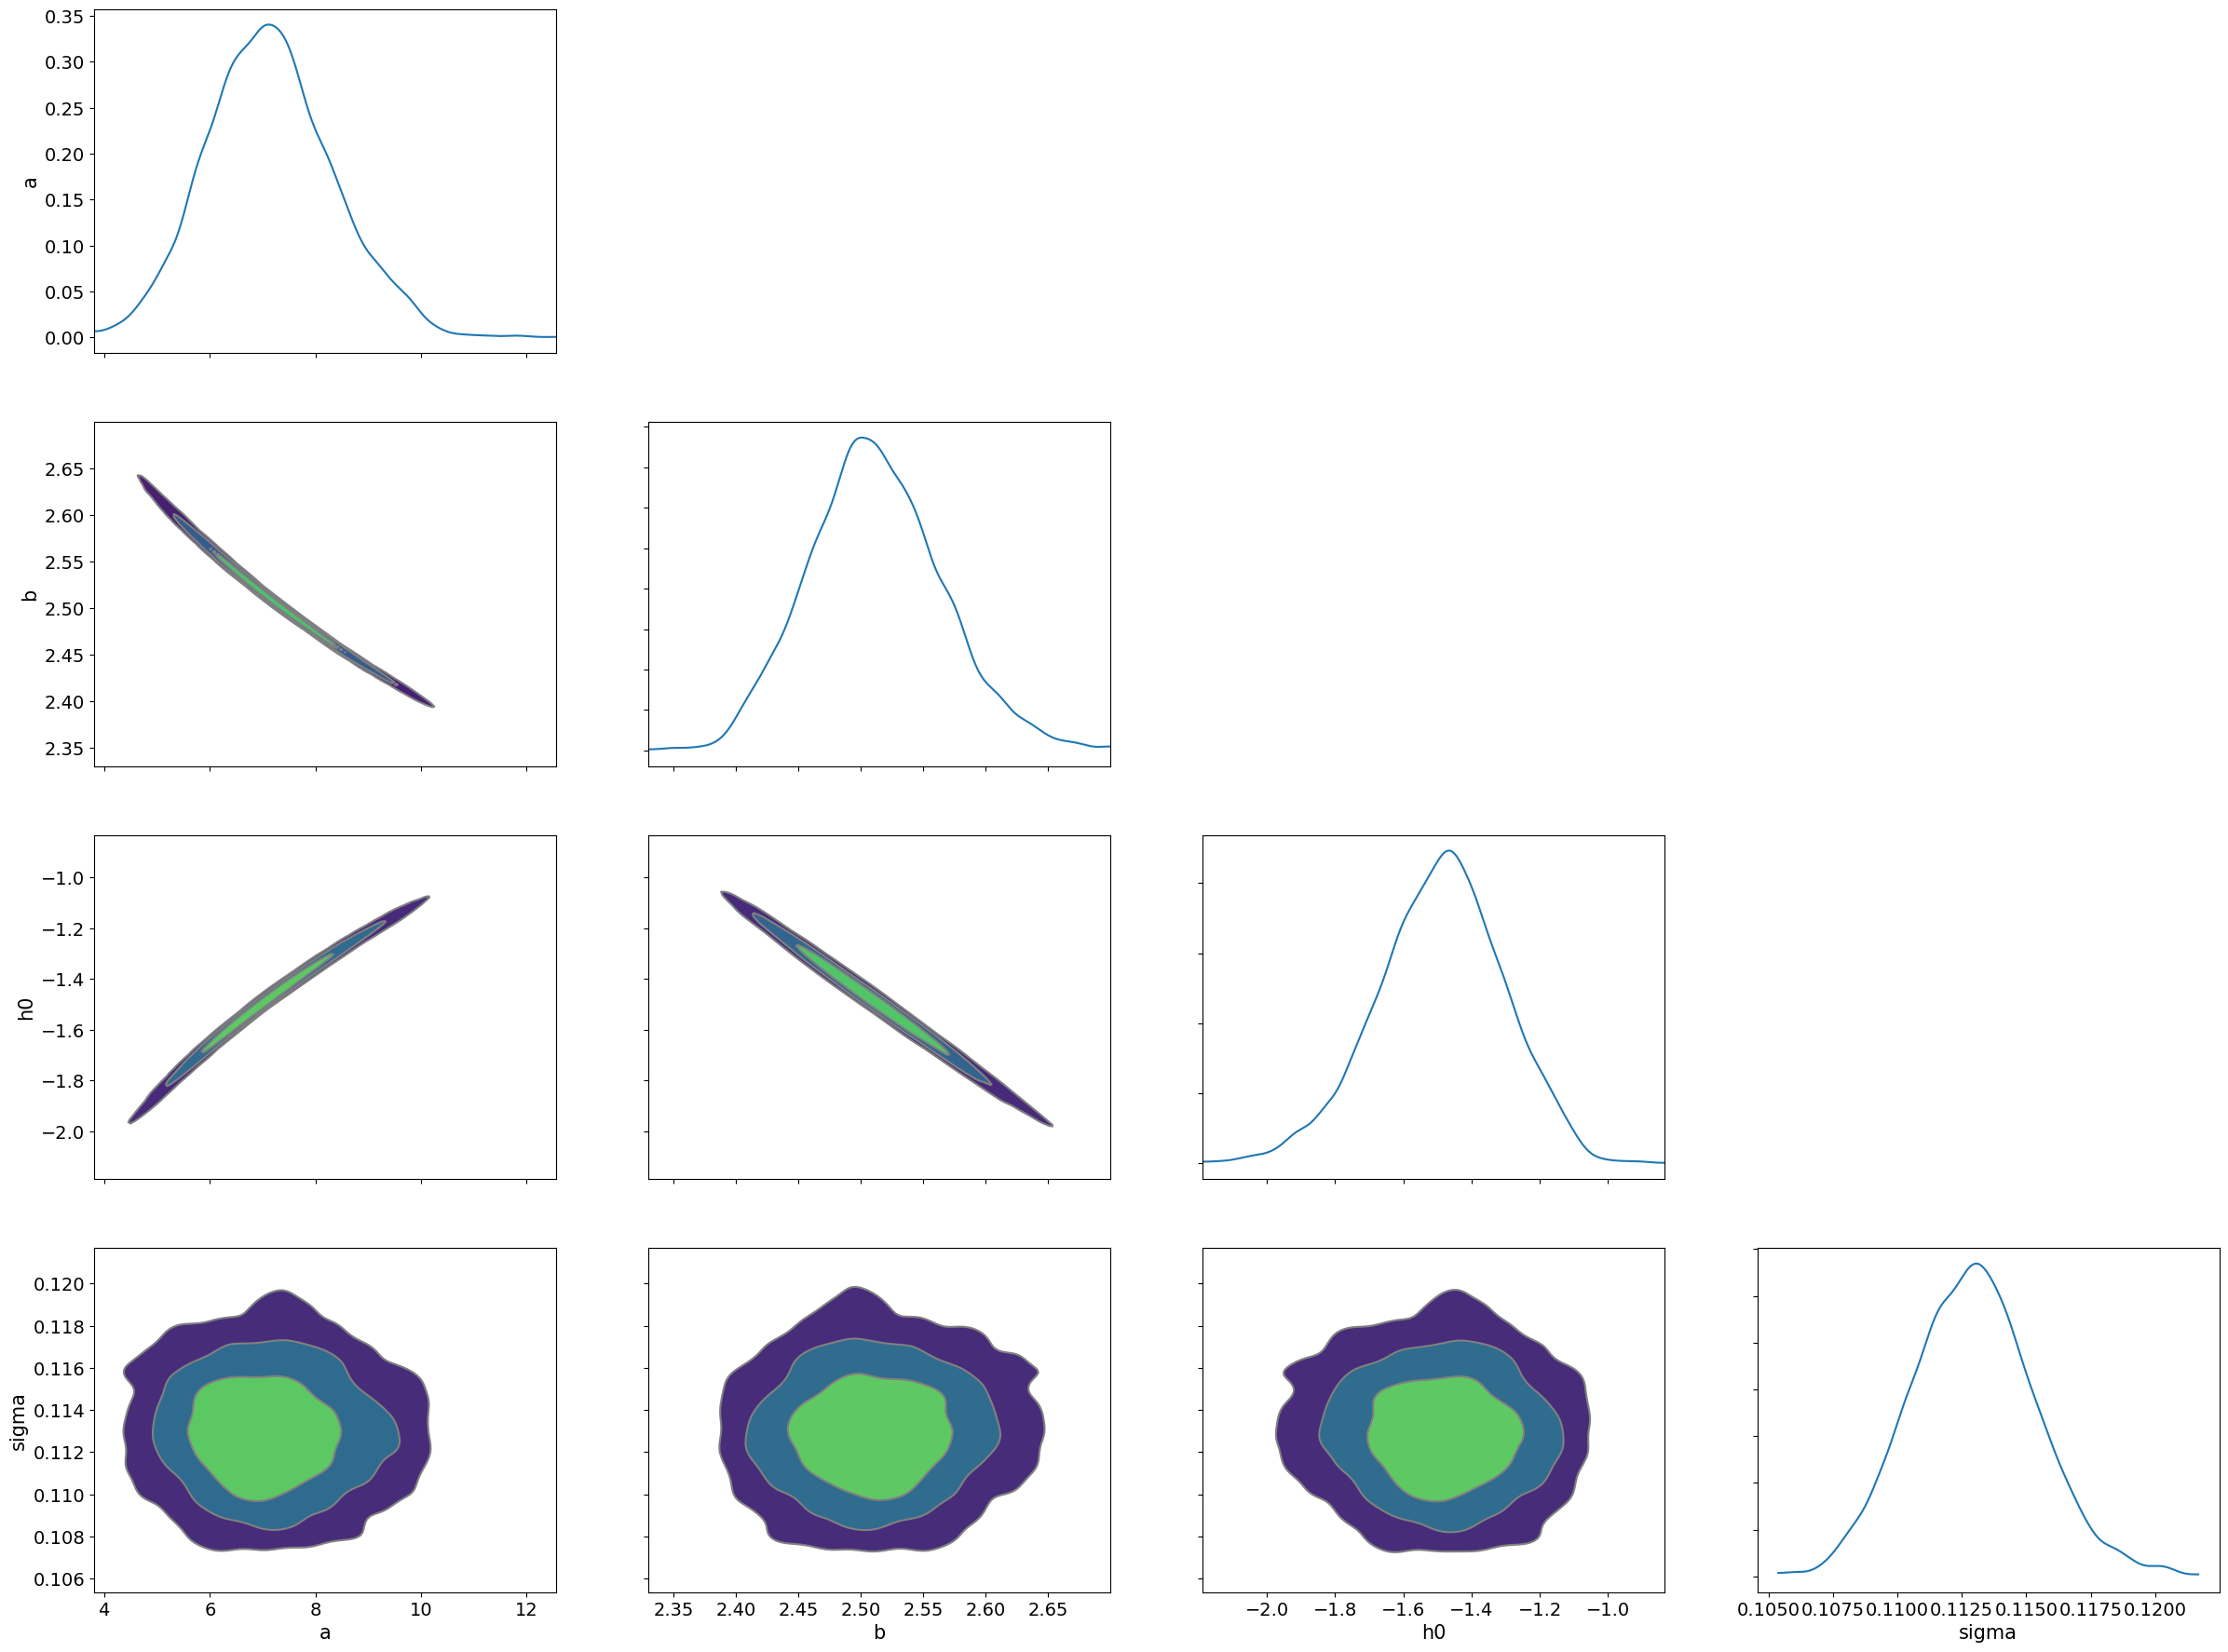

Sampling: [h_obs]


Output()

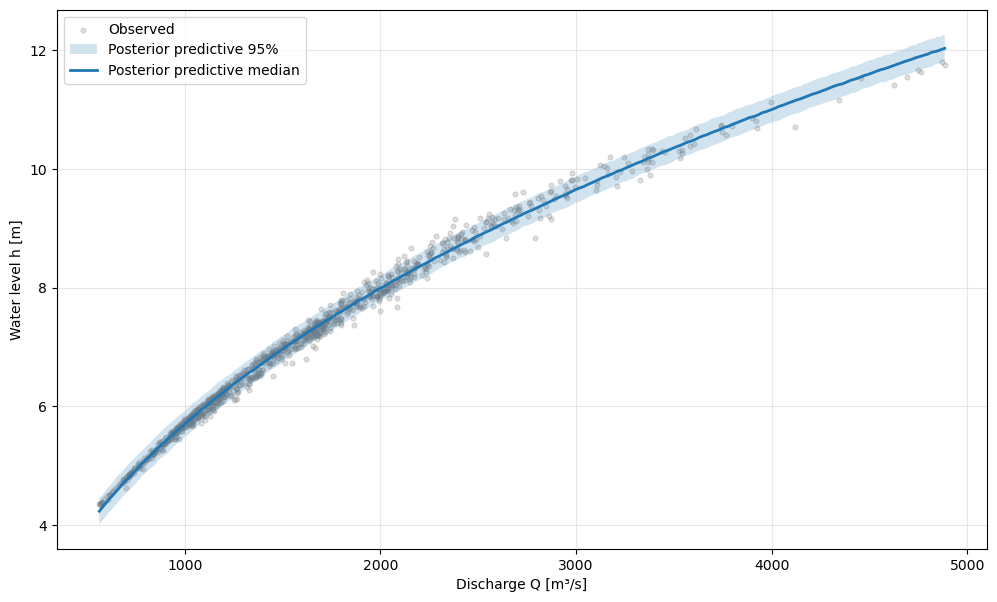

In [7]:
# --- data ---
Q = Q_data.astype(float)
h = h_data.astype(float)

min_h = float(np.min(h))
Q_scale = np.median(Q)
Qn = Q / Q_scale

with pm.Model() as model:
    # Priors
    log_a = pm.Normal("log_a", mu=np.log(25), sigma=1.5)
    a = pm.Deterministic("a", pm.math.exp(log_a))

    log_b = pm.Normal("log_b", mu=np.log(2.0), sigma=0.5)
    b = pm.Deterministic("b", pm.math.exp(log_b))

    h0 = pm.Normal("h0", mu=-1.25, sigma=1.0)

    log_sigma = pm.Normal("log_sigma", mu=np.log(0.1), sigma=0.2)
    sigma = pm.Deterministic("sigma", pm.math.exp(log_sigma))

    a_scaled = pm.Deterministic("a_scaled", a / Q_scale)

    mu = h0 + (pm.math.maximum(Qn / a_scaled, 0.0)) ** (1.0 / b)

    obs = pm.Normal("h_obs", mu=mu, sigma=sigma, observed=h)

    # Sampling
    idata = pm.sample(draws=2000, tune=2000, 
        chains=4, target_accept=0.95, max_treedepth=15, random_seed=42)

print(az.summary(idata, var_names=["a", "b", "h0", "sigma"], round_to=4))
az.plot_trace(idata, var_names=["a", "b", "h0", "sigma"])
plt.show()

az.plot_pair(idata, var_names=["a", "b", "h0", "sigma"], kind="kde", marginals=True)
plt.show()

# Posterior predictive (this includes parameter uncertainty + observation noise)
with model:
    ppc = pm.sample_posterior_predictive(idata, var_names=["h_obs"], random_seed=42)

# Build posterior predictive band over a Q-range
Q_range = np.linspace(Q.min(), Q.max(), 200)
Qn_range = Q_range / Q_scale

# Take posterior draws for parameters
post = idata.posterior
a_s = post["a"].values.reshape(-1)
b_s = post["b"].values.reshape(-1)
h0_s = post["h0"].values.reshape(-1)
sig_s = post["sigma"].values.reshape(-1)

# simulate predictive curves
N = min(2000, a_s.size)
idx = np.random.choice(a_s.size, size=N, replace=False)

pred = np.zeros((N, Q_range.size))
for i, k in enumerate(idx):
    mu_k = h0_s[k] + np.power(np.maximum(Qn_range / (a_s[k] / Q_scale), 0.0), 1.0 / b_s[k])
    pred[i] = mu_k + np.random.normal(0.0, sig_s[k], size=Q_range.size)

lo, med, hi = np.percentile(pred, [2.5, 50, 97.5], axis=0)

plt.figure(figsize=(12, 7))
plt.scatter(Q, h, s=12, alpha=0.25, color="gray", label="Observed")
plt.fill_between(Q_range, lo, hi, alpha=0.2, label="Posterior predictive 95%")
plt.plot(Q_range, med, linewidth=2, label="Posterior predictive median")
plt.xlabel("Discharge Q [m³/s]")
plt.ylabel("Water level h [m]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Stage-Discharge model

In [21]:
def stage_discharge_model(Q, a, b, h0):
    term = np.maximum(Q / a, 0.0)
    return h0 + np.power(term, 1.0 / b)

In [31]:
                      #ess_tail   r_hat  
a, a_r_hat          = 1759.9551,  1.0039  
b, b_r_hat          = 1797.5818,  1.0041  
h0, h0_r_hat        = 1770.0724,  1.0043  
sigma, sigma_r_hat  = 2198.1501,  1.0012 

In [35]:
Q_sim = pd.read_csv("data/discharge_sim.csv")
Q_sim = Q_sim.drop(columns=['5% confidence interval', '95% confidence interval', 'residual error'], errors='ignore')
Q_sim = Q_sim.rename(columns={'50% confidence interval' : 'Q_sim'})
display(Q_sim.head())

,date,Q_sim
0,2014-01-01,2096.373973
1,2014-01-02,2038.281245
2,2014-01-03,1971.266829
3,2014-01-04,1935.585840
4,2014-01-05,1880.921445


In [33]:
h_sim = stage_discharge_model(Q_sim['Q_sim'], a, b, h0)

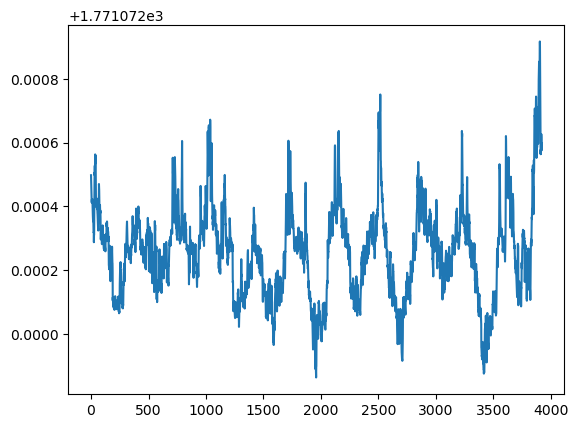

In [34]:
plt.plot(h_sim.index, h_sim)